In [20]:
# Import and create models
import ThrustNN
import torch 

# Thrust Model initializations
input_size = 16
output_size = 7
model_files = [
    "no_dropout16_neurons_5_layers.pt",
    "simple_data_model_not_std_16_neurons_5_layers.pt",
    "simple_data_model_not_std_32_neurons_5_layers.pt",
    "simple_data_model_not_std_64_neurons_5_layers.pt",
    "simple_data_modelv2_16_neurons_5_layers.pt",
    "simple_data_modelv2_32_neurons_5_layers.pt",
    "simple_data_modelv2_64_neurons_5_layers.pt"
]
ThrustModel1 = ThrustNN.thrustFlexNN(input_size=input_size, hidden_size=16, output_size=output_size, hidden_layers=5, dropout_enabled=True)
ThrustModel1.load_state_dict(torch.load('./BestModels/' + model_files[0]))
ThrustModel2 = ThrustNN.thrustFlexNN(input_size=input_size, hidden_size=16, output_size=output_size, hidden_layers=5, dropout_enabled=True)
ThrustModel2.load_state_dict(torch.load('./BestModels/' + model_files[1]))
ThrustModel3 = ThrustNN.thrustFlexNN(input_size=input_size, hidden_size=32, output_size=output_size, hidden_layers=5, dropout_enabled=True)
ThrustModel3.load_state_dict(torch.load('./BestModels/' + model_files[2]))
ThrustModel4 = ThrustNN.thrustFlexNN(input_size=input_size, hidden_size=64, output_size=output_size, hidden_layers=5, dropout_enabled=True)
ThrustModel4.load_state_dict(torch.load('./BestModels/' + model_files[3]))
ThrustModel5 = ThrustNN.thrustFlexNN(input_size=input_size, hidden_size=16, output_size=output_size, hidden_layers=5, dropout_enabled=True)
ThrustModel5.load_state_dict(torch.load('./BestModels/' + model_files[4]))
ThrustModel6 = ThrustNN.thrustFlexNN(input_size=input_size, hidden_size=32, output_size=output_size, hidden_layers=5, dropout_enabled=True)
ThrustModel6.load_state_dict(torch.load('./BestModels/' + model_files[5]))
ThrustModel7 = ThrustNN.thrustFlexNN(input_size=input_size, hidden_size=64, output_size=output_size, hidden_layers=5, dropout_enabled=True)
ThrustModel7.load_state_dict(torch.load('./BestModels/' + model_files[6]))

ThrustModels = [ ThrustModel2, ThrustModel3, ThrustModel4,ThrustModel1, ThrustModel5, ThrustModel6, ThrustModel7]

In [21]:
# load Matlab data
import scipy.io
import numpy as np

data = scipy.io.loadmat('./data2025-10-17_23-21-22.mat')
data_keys = ['xout', 'Tail_Forces_out', 'Tail_Centre_out', 'cout', 'cal_stout', 'Moments_Add_out']

# Create a dictionary to hold the data (labels as keys and numpy arrays as values)
data_dict = {key: np.array(data[key]) for key in data_keys}


In [22]:
# Prepare input for Thrust Model with simulation data
#load scalers used during training
import joblib
scaler_in = joblib.load('./scaler_thrust_in.pkl')
scaler_out = joblib.load('./scaler_thrust_out.pkl')
# Concatenate inputs for Thrust Model
caudal_old = np.hstack((np.zeros(1),data_dict['cout'][:-1, 0])).reshape(-1,1)  # Previous caudal angle (shifted by one timestep)
print(caudal_old.shape)
in_thrust = np.hstack((data_dict['xout'], data_dict['cout'], caudal_old, data_dict['Tail_Centre_out']))  # Input: fluid velocity, caudal angle, previous caudal angle, tail forces
print(in_thrust.shape)
# Scale input data 
#keep scaled and non-scaled tensors for comparison
in_thrust_scaled = scaler_in.transform(in_thrust)  # Scale input data
# Convert to tensor
in_thrust_tensor_scaled = torch.from_numpy(in_thrust_scaled).float()
in_thrust_tensor = torch.from_numpy(in_thrust).float()
# Prepare target output for Thrust Model
thrust_target = data_dict['Tail_Forces_out']  # Target output: thrust forces
print(thrust_target.shape)
# Exclude all columns that are zero constants
thrust_target = thrust_target[:, ~np.all(thrust_target == 0, axis=0)]
# Scale target data
thrust_target_scaled = scaler_out.transform(thrust_target)  # Scale target data
# Convert to tensor
thrust_target_tensor_scaled = torch.from_numpy(thrust_target_scaled).float()
thrust_target_tensor = torch.from_numpy(thrust_target).float()
print(thrust_target_tensor.shape)

(10000, 1)
(10000, 16)
(10000, 12)
torch.Size([10000, 7])


In [23]:
# Function to evaluate models
import matplotlib.pyplot as plt 
from torcheval.metrics.functional import r2_score, mean_squared_error
def evaluate_models(model, input_tensor, target_tensor):
    with torch.no_grad():
        model.eval()
        thrust_preds = model(input_tensor)
        print(thrust_preds.shape)
    mse_thrust = mean_squared_error(thrust_preds, target_tensor)
    r2_thrust = r2_score(thrust_preds, target_tensor)
    print(f"Thrust Model - MSE: {mse_thrust.item()}, R2: {r2_thrust.item()}")

    force_labels = ['Xt', 'Xdn', 'Yt', 'Ydn', 'Kdn', 'Nt', 'Ndn']
    time = np.arange(thrust_target_tensor.shape[0]) * 1e-3   
    plt.figure(figsize=(15, 20))
    for i in range(thrust_target_tensor.shape[1]):
        plt.subplot(12, 2, (i*2)+1)
        plt.plot(time, thrust_target_tensor[:, i], label='Actual', color='blue')
        plt.subplot(12, 2, (i*2)+2)
        plt.plot(time, thrust_preds[:, i].numpy(), label='Predicted', color='orange')
        plt.title(f' {force_labels[i]}')
        plt.xlabel('Time Step')
        plt.ylabel('Force Value')
        plt.legend()
        plt.grid()
    plt.tight_layout()
    plt.show()

Evaluating Thrust Model no_dropout16_neurons_5_layers.pt
torch.Size([10000, 7])
Thrust Model - MSE: 0.20614957809448242, R2: 0.7590485215187073


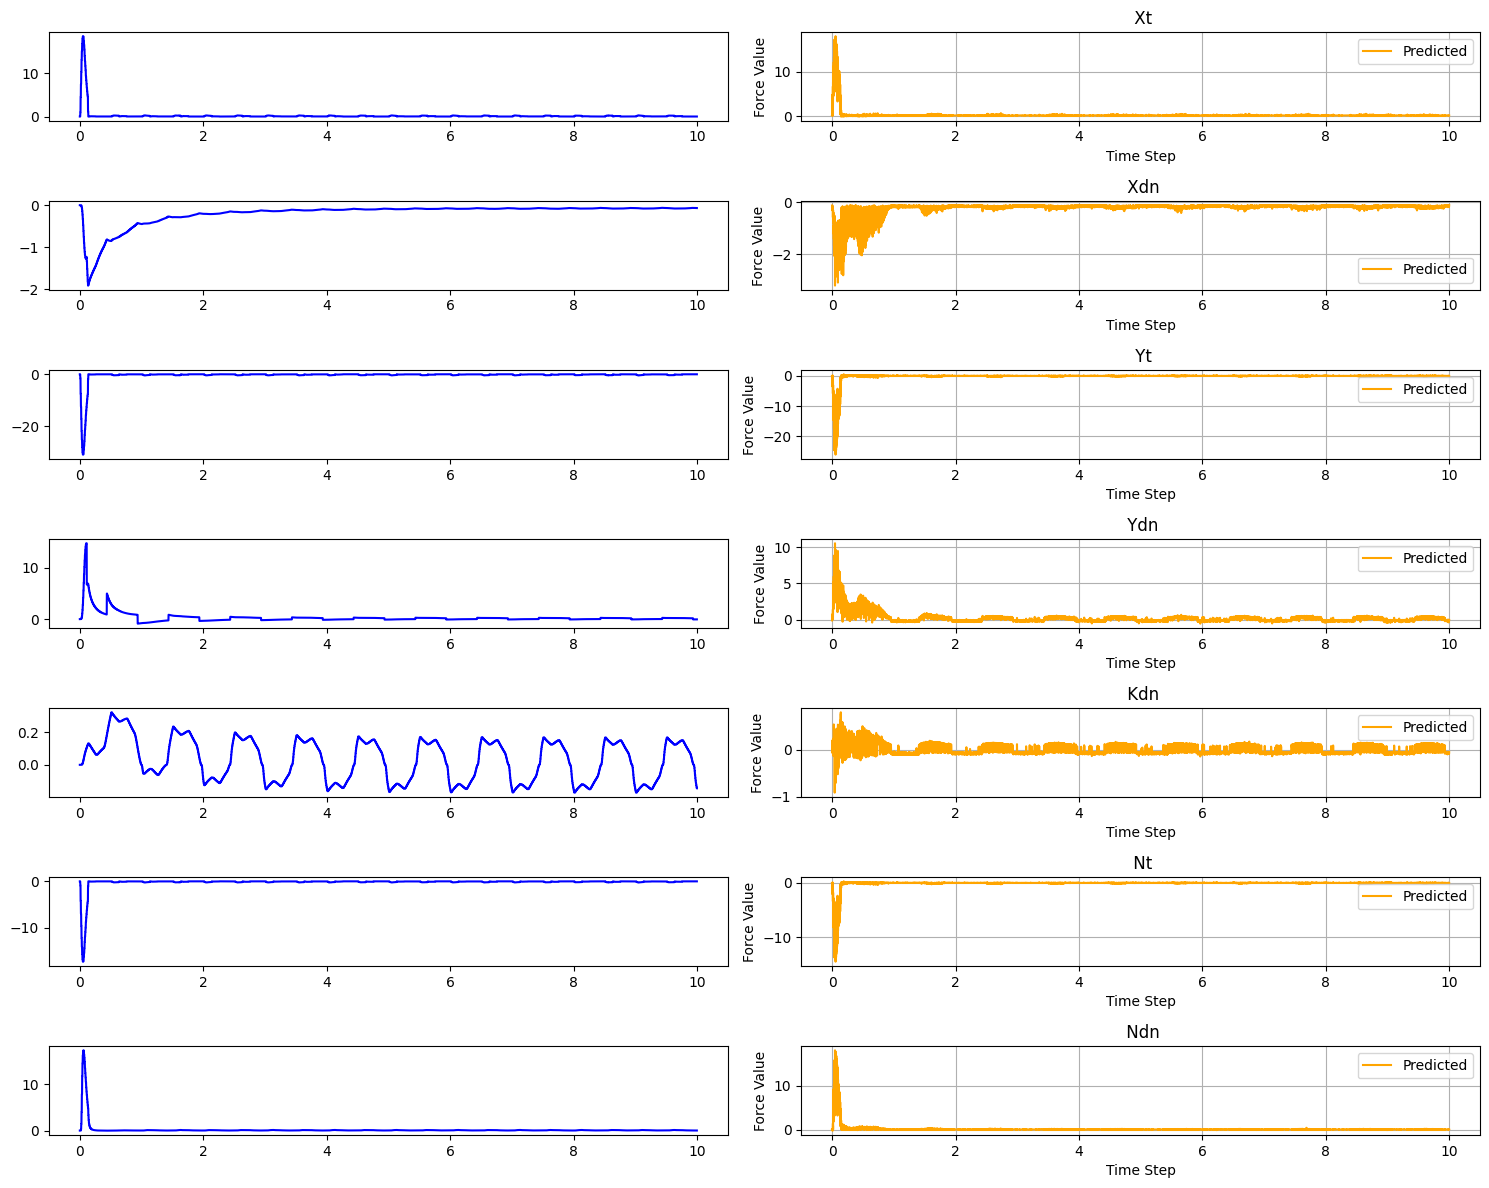

Evaluating Thrust Model simple_data_model_not_std_16_neurons_5_layers.pt
torch.Size([10000, 7])
Thrust Model - MSE: 0.2536775767803192, R2: 0.7302185893058777


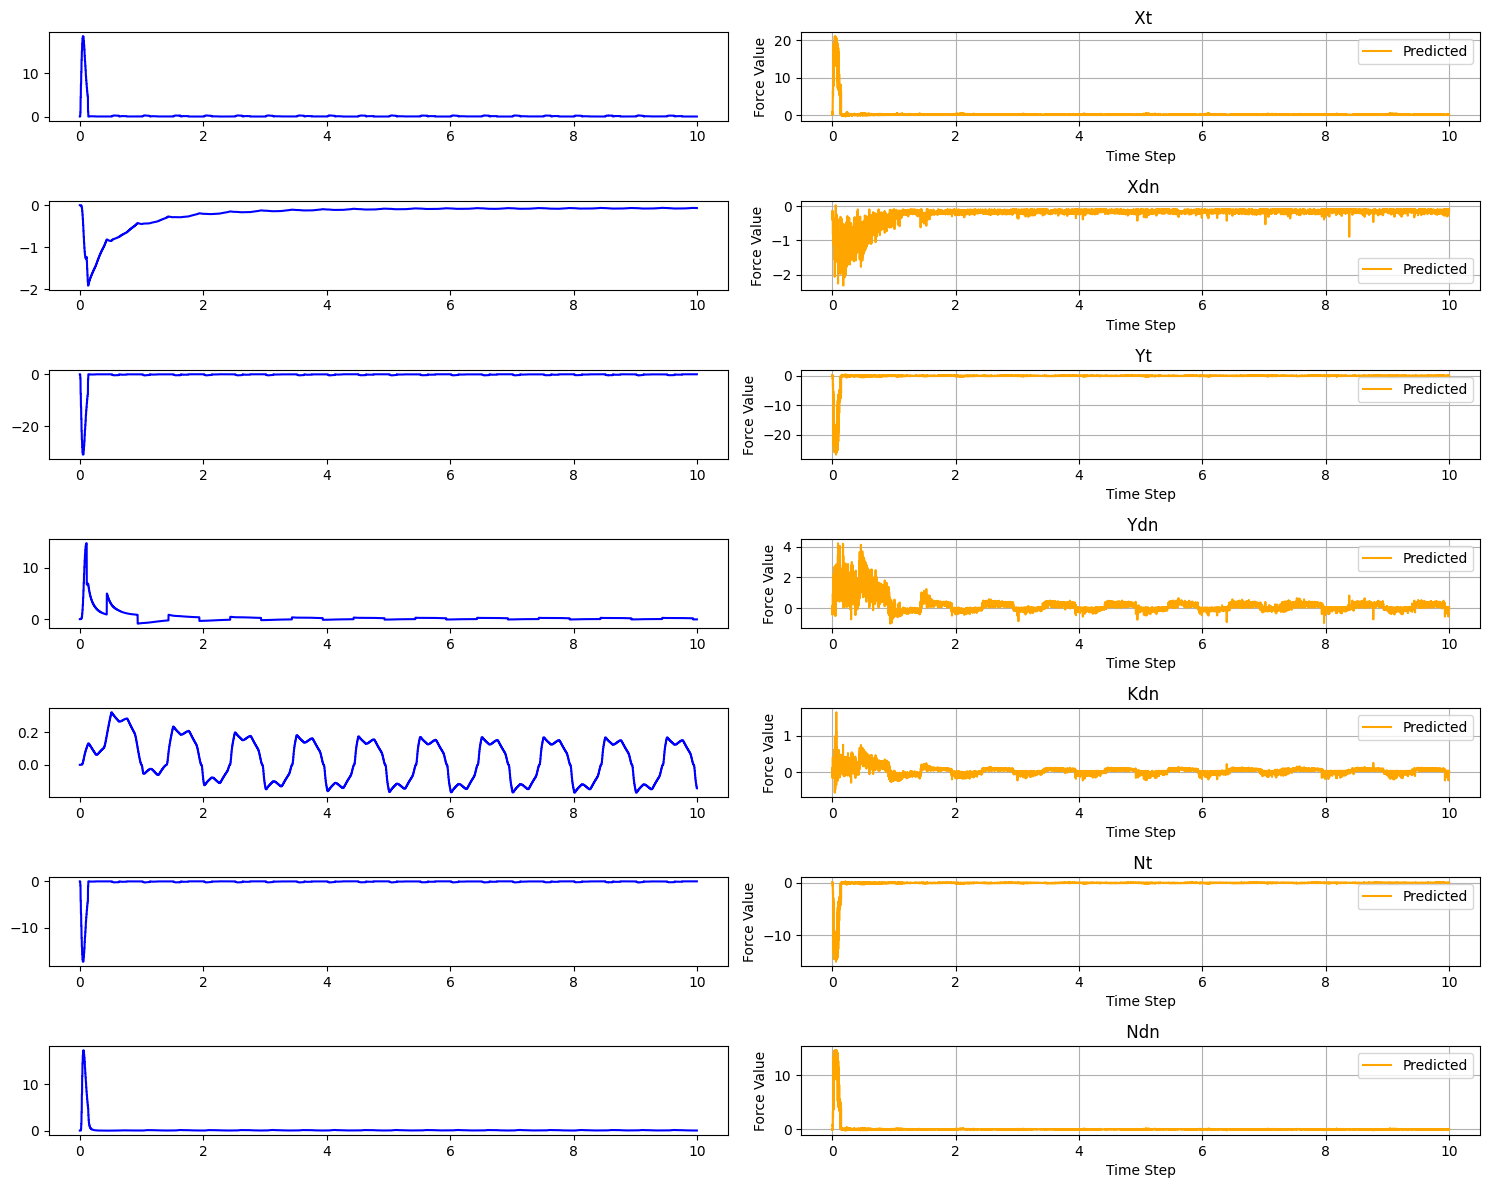

Evaluating Thrust Model simple_data_model_not_std_32_neurons_5_layers.pt
torch.Size([10000, 7])
Thrust Model - MSE: 0.5824918150901794, R2: 0.7100678086280823


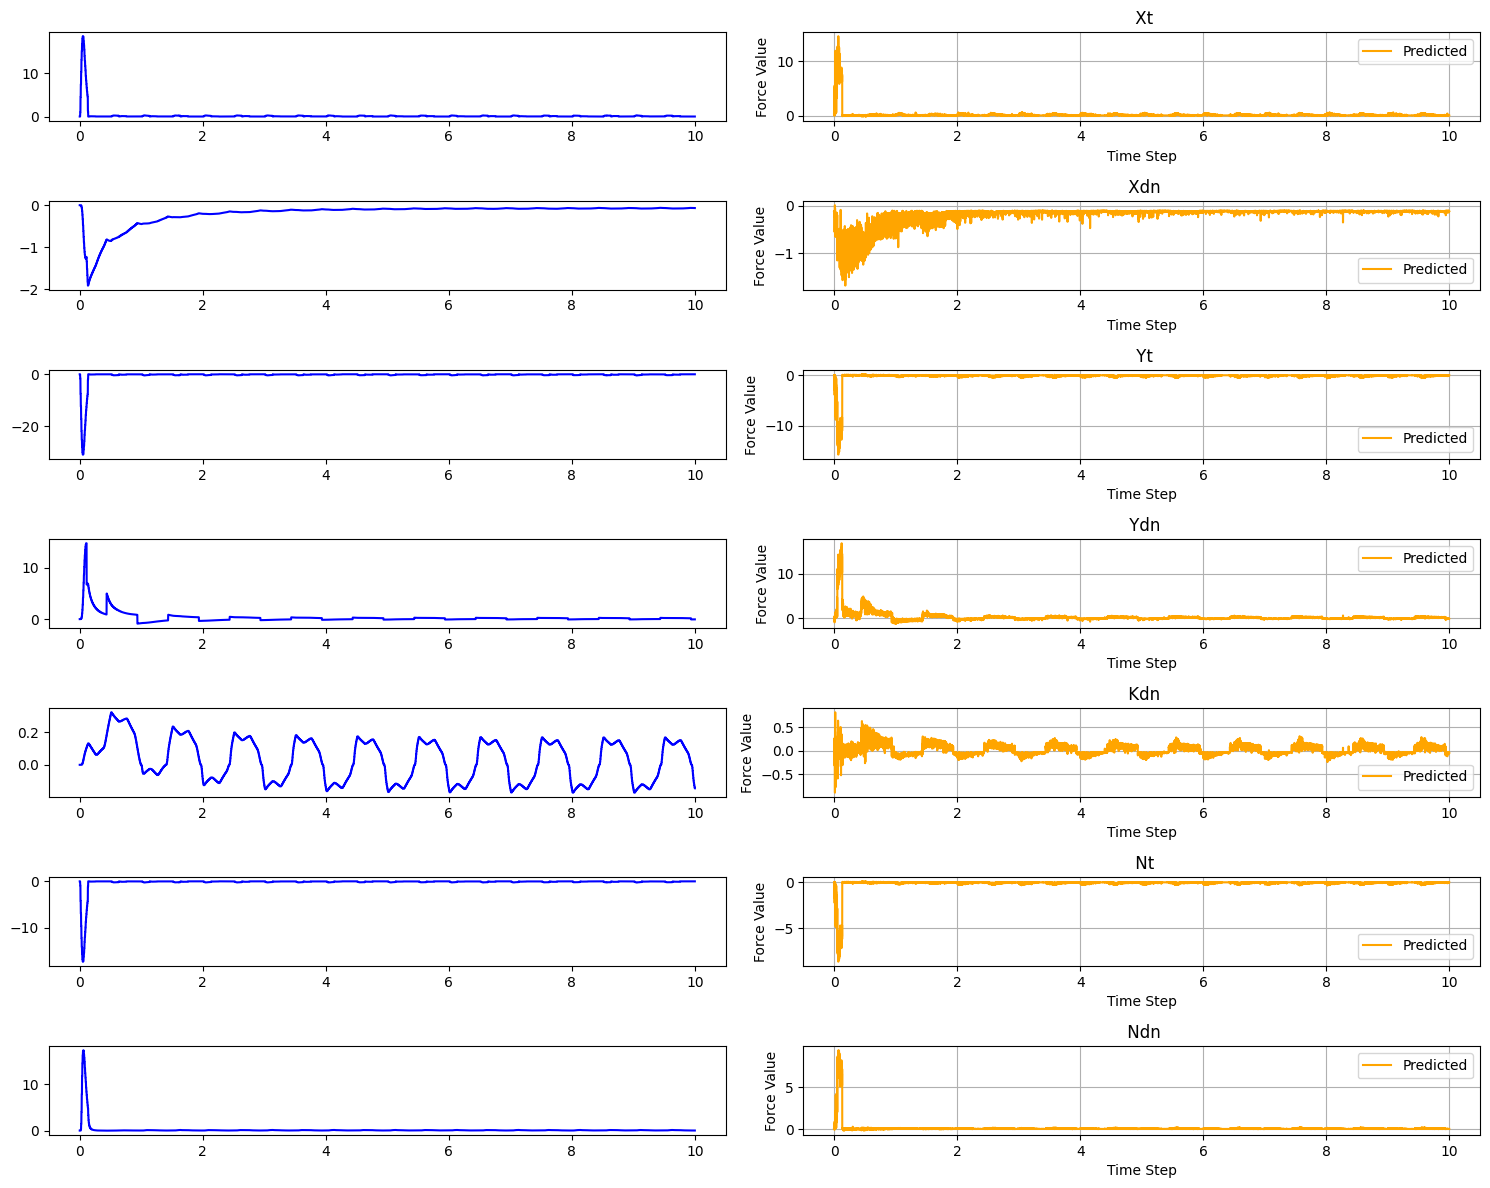

In [24]:
# Evaluate each non-scaled models
for idx in range(3):
    print(f"Evaluating Thrust Model {model_files[idx]}")
    evaluate_models(ThrustModels[idx], in_thrust_tensor, thrust_target_tensor)

Evaluating Thrust Model no_dropout16_neurons_5_layers.pt
torch.Size([10000, 7])
Thrust Model - MSE: 68.48393249511719, R2: -15.835545539855957


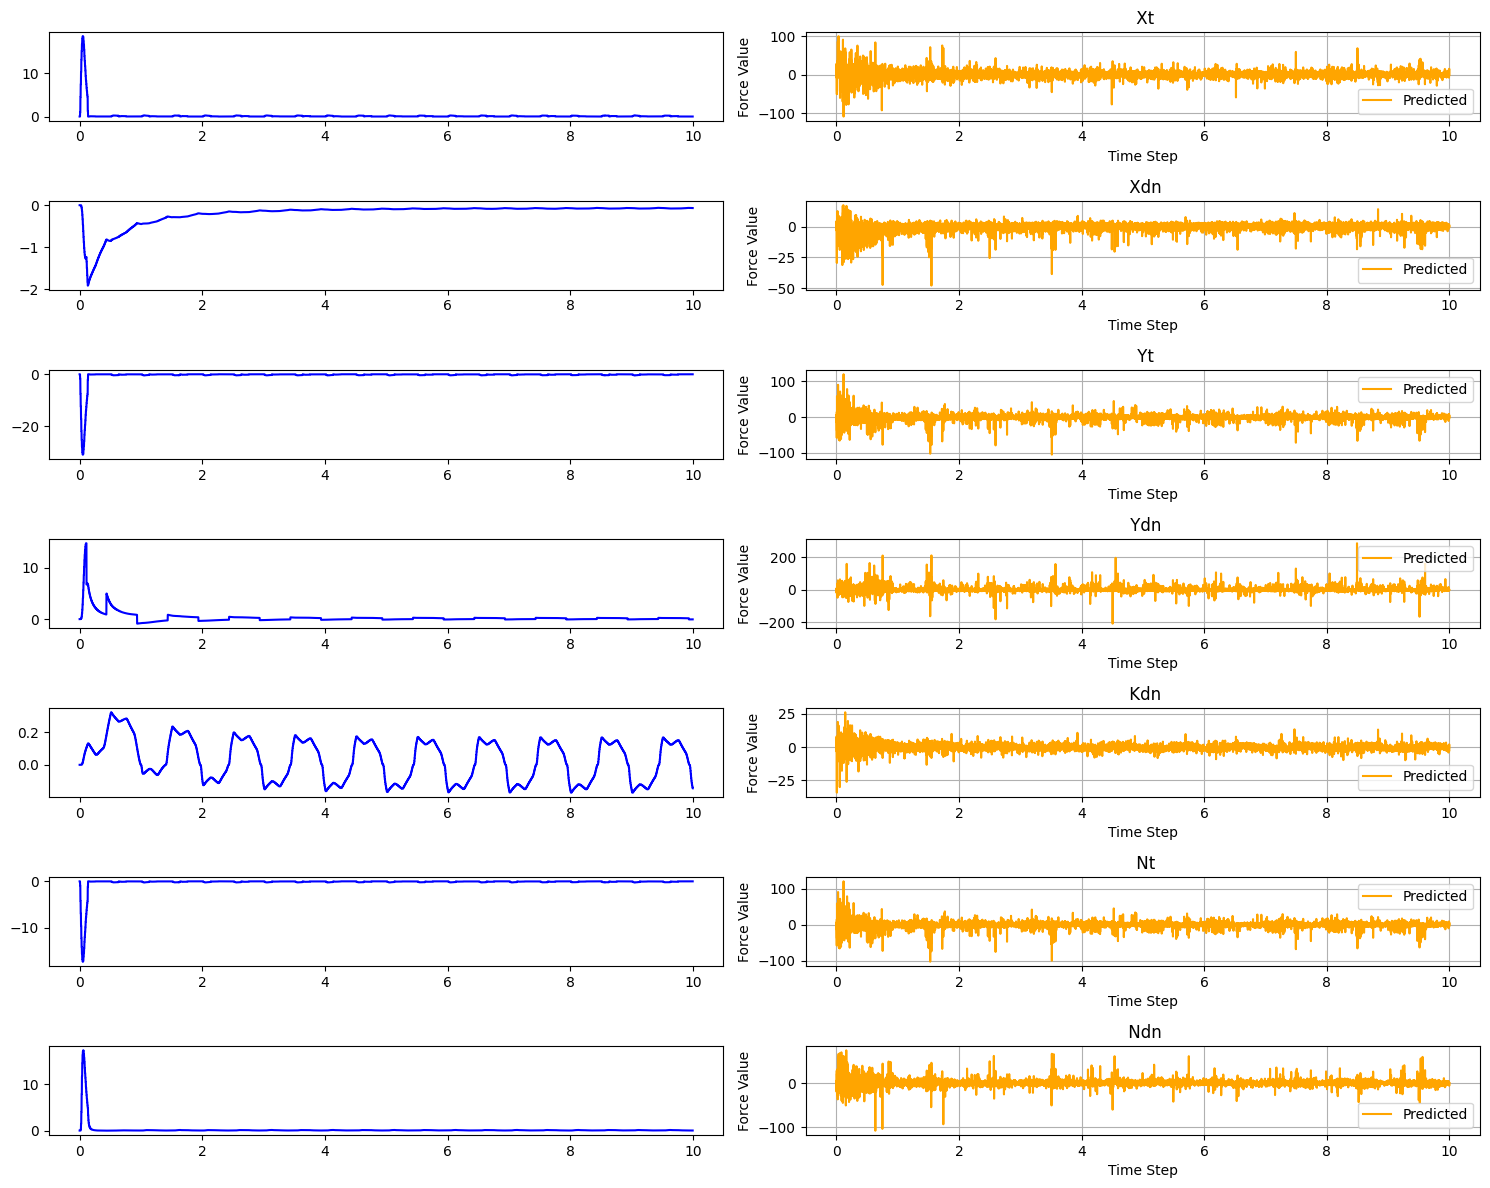

Evaluating Thrust Model simple_data_model_not_std_16_neurons_5_layers.pt
torch.Size([10000, 7])
Thrust Model - MSE: 0.5946665406227112, R2: 0.8465790152549744


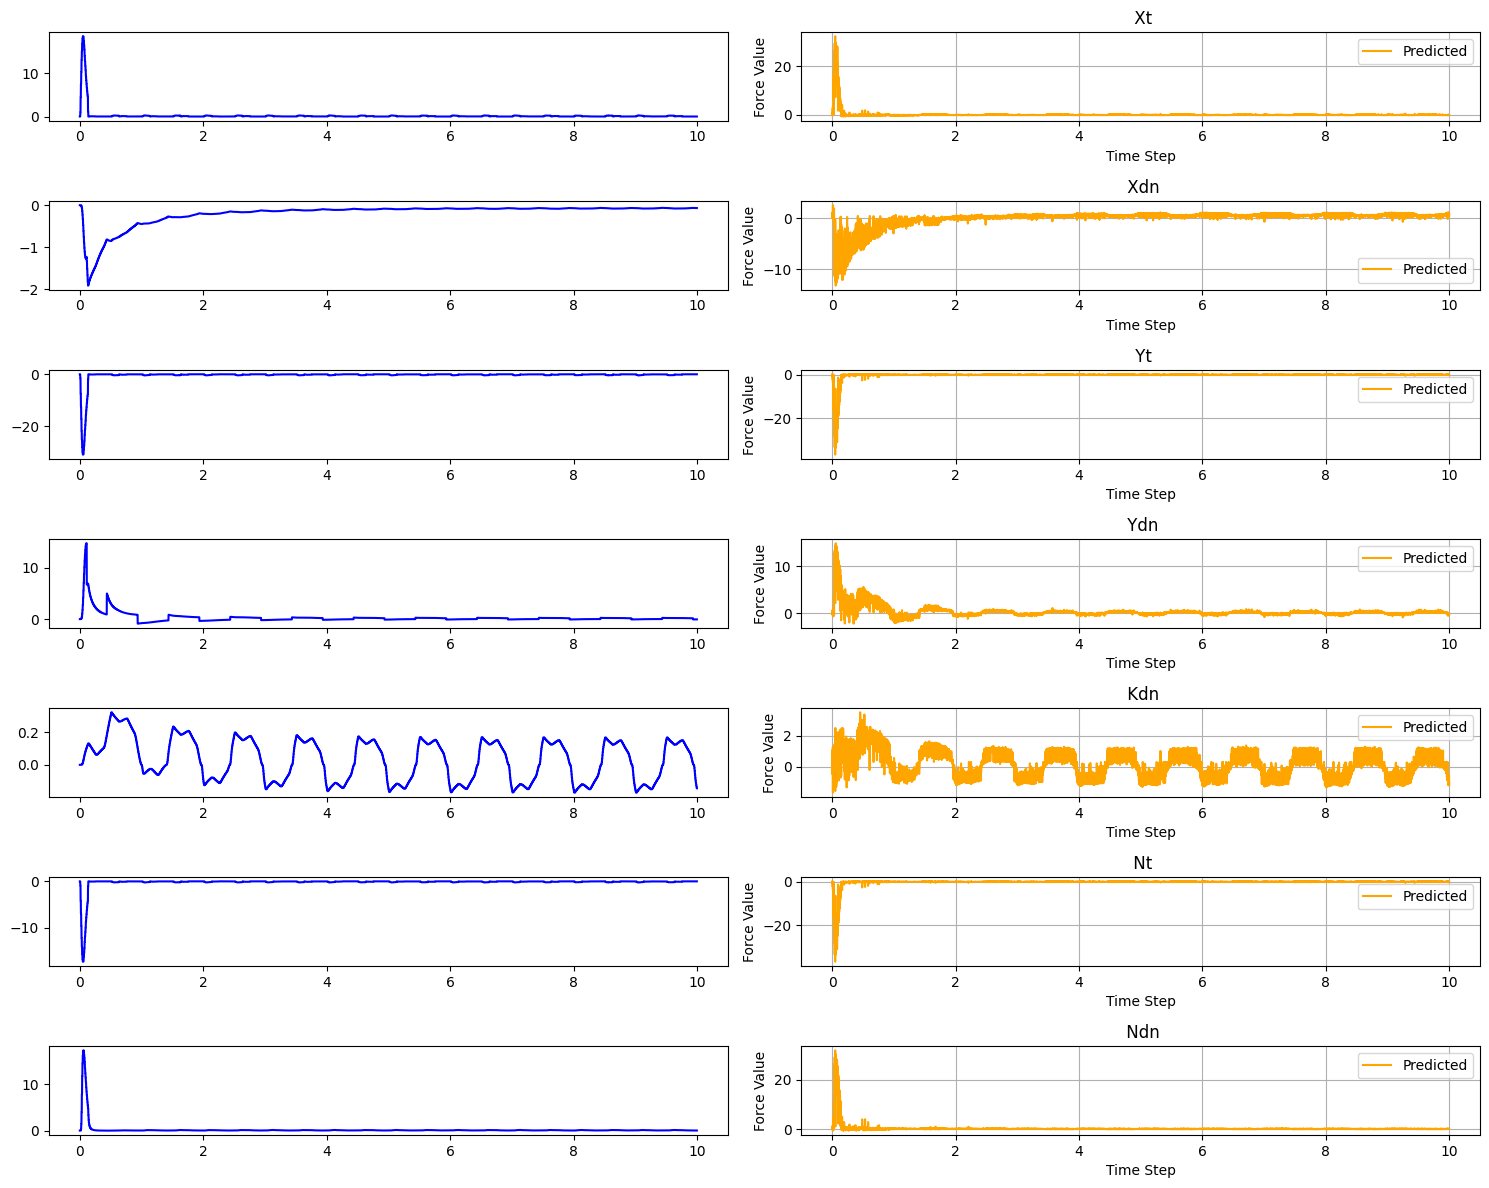

Evaluating Thrust Model simple_data_model_not_std_32_neurons_5_layers.pt
torch.Size([10000, 7])
Thrust Model - MSE: 0.40430569648742676, R2: 0.8949876427650452


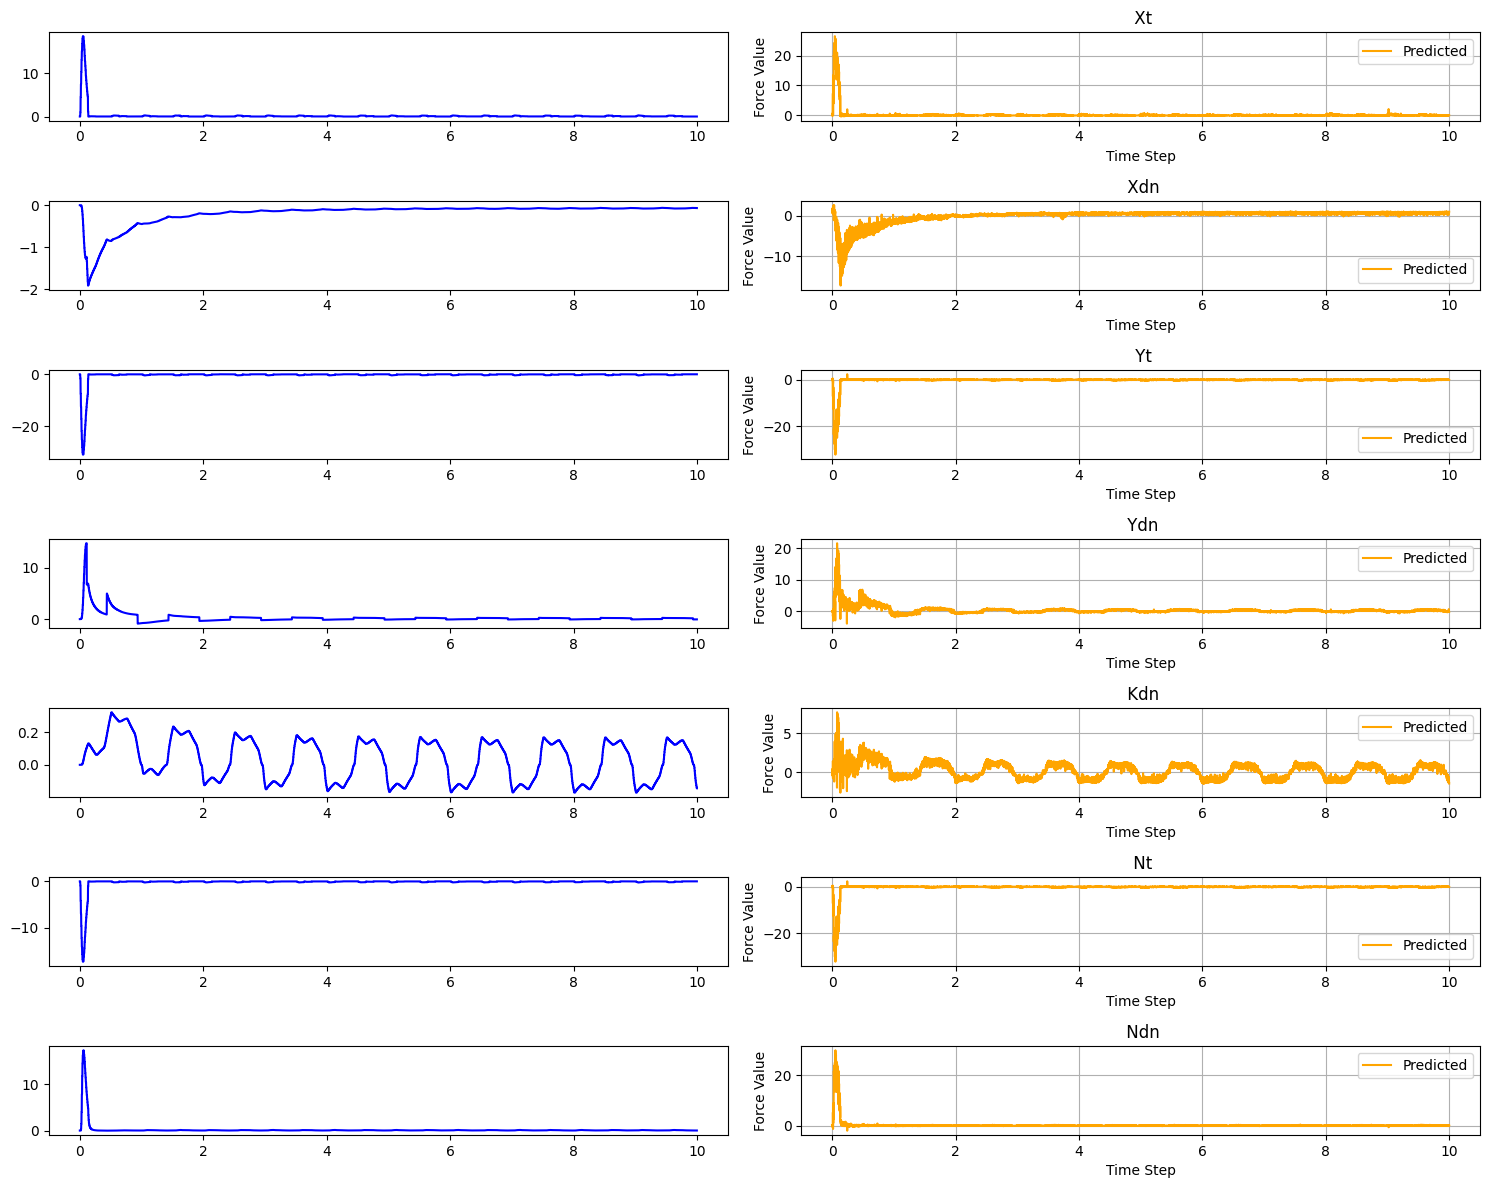

Evaluating Thrust Model simple_data_model_not_std_64_neurons_5_layers.pt
torch.Size([10000, 7])
Thrust Model - MSE: 0.6837185621261597, R2: 0.8557395339012146


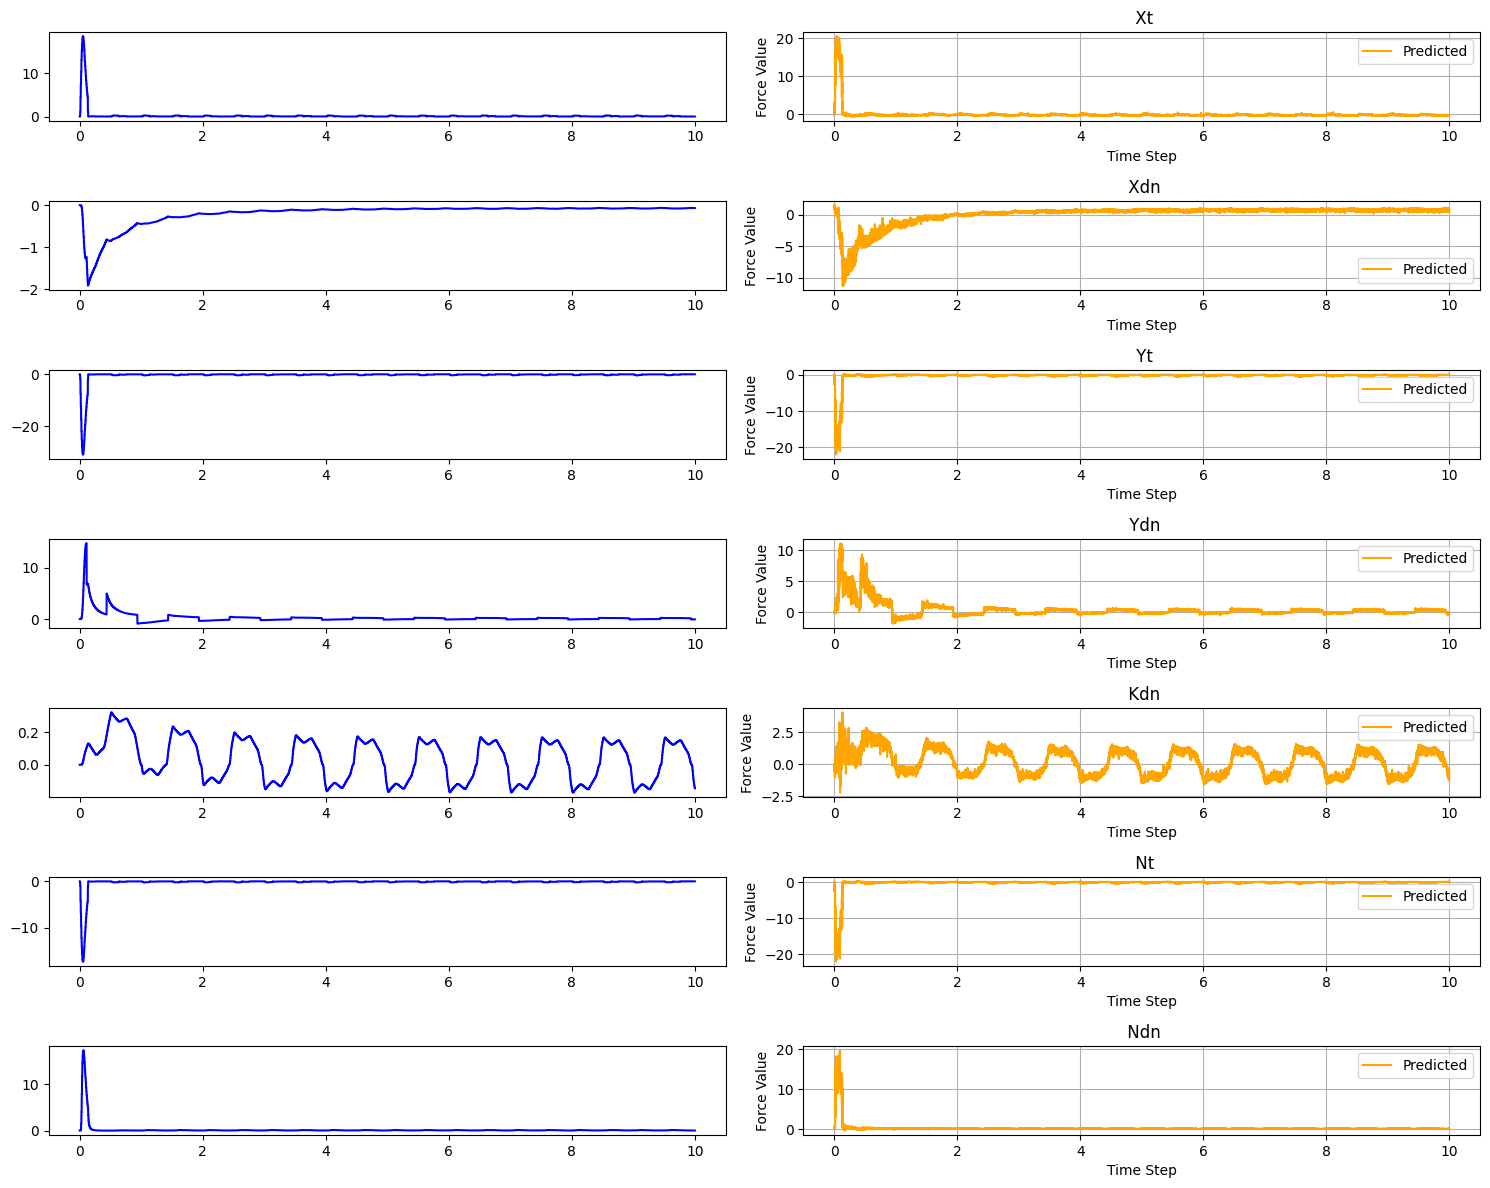

In [26]:
# Evaluate scaled models
for idx in range(4):
    print(f"Evaluating Thrust Model {model_files[idx]}")
    evaluate_models(ThrustModels[idx+3], in_thrust_tensor_scaled, thrust_target_tensor_scaled)